# HW02 — EDA: Wisconsin Breast Cancer Dataset

Датасет: Breast Cancer Wisconsin (Diagnostic)  
Оригинал: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Это 569 образцов биопсий опухолей молочной железы. Для каждого посчитали 30 числовых признаков (mean, se и worst) на основе изображения тонкоигольной биопсии. Задача — предсказать, злокачественная опухоль (M) или доброкачественная (B)

Признаки описывают характеристики клеточных ядер: радиус, текстура, периметр, площадь, гладкость, компактность, вогнутость и т.д

Я решила сделать полноценный EDA, чтобы лучше понять, как эти признаки связаны с диагнозом и насколько хорошо классы разделяются

## 0. Импорты

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder, StandardScaler
import category_encoders as ce

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
print("done")



done


In [2]:
import numpy
import pandas
import seaborn
import sklearn


---
## A. Быстрый обзор данных

In [3]:
df = pd.read_csv('breast_cancer.csv')

print("shape:", df.shape)


shape: (569, 32)


In [4]:
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dim_worst
0,842302,B,12.4003,15.1051,63.5648,406.5622,0.0942,0.0838,0.1640,0.0505,...,14.7191,25.4404,94.2810,714.9620,0.1278,0.2507,0.1190,0.0770,0.3261,0.0569
1,842303,B,7.6583,18.1087,85.3717,699.0811,0.0869,0.1011,0.0219,0.0130,...,15.9693,20.5343,120.7127,473.3073,0.1049,0.2157,0.6493,0.1554,0.3452,0.0950
2,842304,B,11.0266,15.6357,60.6690,309.7359,0.1064,0.0933,0.0573,0.0148,...,11.6677,27.8128,119.3358,826.1037,0.1296,0.2327,0.2611,0.1545,0.2490,0.0689
3,842305,B,14.6689,20.3438,109.3923,340.3714,0.1072,0.0630,0.1312,0.0010,...,11.9158,29.4703,103.1185,699.7218,0.1368,0.2659,0.1288,0.0895,0.2371,0.0848
4,842306,M,19.4631,22.9772,116.0399,789.3633,0.1206,0.1635,0.1493,0.0713,...,22.9189,32.9151,151.6930,1623.9380,0.1276,0.2050,0.6838,0.1208,0.2235,0.0920


In [5]:
df.tail()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dim_worst
564,842866,M,19.4778,20.6154,119.4046,NaN,0.0970,0.0667,0.1934,0.0908,...,22.6739,30.6670,149.8334,1577.9350,0.1620,0.2542,0.6966,0.1520,0.2607,0.1088
565,842867,B,13.2466,18.1345,65.0757,350.6274,0.0730,0.0010,0.0371,0.0010,...,15.2925,21.8826,108.8335,481.5535,0.1508,0.1175,0.2027,0.1204,0.3026,0.0647
566,842868,B,11.0131,19.7058,83.1125,389.2041,0.0800,0.1086,0.0728,0.0552,...,14.9896,17.0349,88.2836,501.1853,0.1205,0.0010,0.4329,0.0010,0.2769,0.0751
567,842869,B,11.1100,12.4311,96.3689,646.6312,0.0823,0.0922,0.0942,0.0179,...,15.2539,25.8105,69.0204,978.0305,0.1151,0.1888,0.8694,0.1187,0.2785,0.0781
568,842870,B,12.5510,16.0483,82.2342,714.7521,0.0913,0.0255,0.0010,0.0289,...,14.9614,19.5049,126.0642,293.0559,0.1122,0.3181,0.2910,0.1539,0.2334,0.1048


In [6]:

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    569 non-null    int64  
 1   diagnosis             569 non-null    str    
 2   radius_mean           569 non-null    float64
 3   texture_mean          569 non-null    float64
 4   perimeter_mean        569 non-null    float64
 5   area_mean             555 non-null    float64
 6   smoothness_mean       569 non-null    float64
 7   compactness_mean      564 non-null    float64
 8   concavity_mean        569 non-null    float64
 9   concave_points_mean   569 non-null    float64
 10  symmetry_mean         569 non-null    float64
 11  fractal_dim_mean      569 non-null    float64
 12  radius_se             569 non-null    float64
 13  texture_se            564 non-null    float64
 14  perimeter_se          569 non-null    float64
 15  area_se               555 non-null

In [7]:
# describe() только для числовых (count, mean, std, min/max, квартили)
df.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,555.000000,569.000000,564.000000,569.000000,569.000000,569.000000,...,569.000000,564.000000,569.000000,562.000000,561.000000,559.000000,569.000000,559.000000,569.000000,558.000000
mean,842586.000000,13.937887,19.565859,93.985311,682.000733,0.095060,0.102311,0.094978,0.051472,0.181045,...,16.921620,26.793437,114.257243,881.997030,0.135479,0.266398,0.346438,0.138463,0.305478,0.085603
std,164.400426,3.407723,4.010202,32.750142,351.710044,0.013777,0.056289,0.076425,0.040493,0.026320,...,4.490373,5.328171,28.900385,543.475980,0.020434,0.141607,0.207958,0.068038,0.059702,0.018675
min,842302.000000,6.518100,7.847100,43.695500,66.637800,0.058300,0.001000,0.001000,0.001000,0.101600,...,5.568800,9.721900,35.016800,0.001000,0.062200,0.001000,0.001000,0.001000,0.111300,0.011400
25%,842444.000000,11.304000,16.818100,75.137500,434.568800,0.085200,0.060300,0.028500,0.016700,0.162500,...,13.561200,23.074575,91.704600,468.431775,0.120700,0.170650,0.195300,0.090950,0.264400,0.073000
50%,842586.000000,13.430000,19.561400,88.845000,600.247500,0.094600,0.101150,0.089000,0.047600,0.181900,...,16.255400,26.979200,112.751200,778.874700,0.137000,0.264600,0.328800,0.135700,0.305300,0.085250
75%,842728.000000,16.759400,22.292700,110.385200,924.768450,0.104500,0.143250,0.148300,0.083500,0.200800,...,20.109400,30.561600,133.191500,1294.527675,0.150400,0.363250,0.488900,0.184100,0.344300,0.098700
max,842870.000000,23.067600,30.325500,416.638317,3278.361503,0.136200,0.307200,0.385800,0.169800,0.262100,...,30.700900,40.511100,205.856600,3532.784183,0.192400,0.778600,0.895600,0.384600,0.487300,0.140100


In [8]:
# describe для строковых (object) покажет diagnosis и id
df.describe(include='object')


,diagnosis
count,569
unique,2
top,B
freq,358


In [9]:
# Проверка пропусков
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'пропусков': missing, '%': missing_pct})
print(miss_df[miss_df['пропусков'] > 0])


                      пропусков     %
area_mean                    14  2.46
compactness_mean              5  0.88
texture_se                    5  0.88
area_se                      14  2.46
texture_worst                 5  0.88
area_worst                    7  1.23
smoothness_worst              8  1.41
compactness_worst            10  1.76
concave_points_worst         10  1.76
fractal_dim_worst            11  1.93


In [10]:
# Дубликаты
print(f"Дубликатов: {df.duplicated().sum()}")

# Распределение целевой переменной
print("\nРаспределение diagnosis:")
print(df['diagnosis'].value_counts())
print(f"Доля злокачественных (M): {(df['diagnosis']=='M').mean():.1%}")


Дубликатов: 0

Распределение diagnosis:
diagnosis
B    358
M    211
Name: count, dtype: int64
Доля злокачественных (M): 37.1%


 Вывод     
 
  569 образцов, 32 колонки (id, diagnosis + 30 числовых признаков). Пропуски есть в ~10 колонках — в основном площадь и компактность. Дубликатов нет. Классы немного несбалансированы: 63% доброкачественных (B), 37% злокачественных (M) — типично для медицинских датасетов.


In [11]:
df_clean = df.copy()

# Смотрим на пропуски детально. Коррелируют ли они вообще с диагнозом?
for col in df_clean.columns[df_clean.isnull().any()]:
    miss_M = df_clean[df_clean['diagnosis']=='M'][col].isnull().sum()
    miss_B = df_clean[df_clean['diagnosis']=='B'][col].isnull().sum()
    print(f"{col:30s} | M: {miss_M:3d}  B: {miss_B:3d}")


area_mean                      | M:   4  B:  10
compactness_mean               | M:   2  B:   3
texture_se                     | M:   3  B:   2
area_se                        | M:   2  B:  12
texture_worst                  | M:   2  B:   3
area_worst                     | M:   4  B:   3
smoothness_worst               | M:   3  B:   5
compactness_worst              | M:   7  B:   3
concave_points_worst           | M:   2  B:   8
fractal_dim_worst              | M:   5  B:   6


In [12]:
# Числовые колонки заполняем медианой
# Почему медиана, а не среднее?
# Потому что у нас могут быть выбросы (особенно в area_*),
# и медиана более устойчива к ним чем среднее
num_cols = df_clean.select_dtypes(include='number').columns.tolist()
num_cols.remove('id')  # id не нужен для заполнения

for col in num_cols:
    med = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(med)

print("Пропуски после fillna(median):")
print(df_clean.isnull().sum().sum(), "(должно быть 0)")


Пропуски после fillna(median):
0 (должно быть 0)


In [13]:
# Показываем разницу до/после для одной колонки
print("area_mean ДО очистки:")
print(df['area_mean'].describe())
print("\narea_mean ПОСЛЕ (медиана заполнила пропуски):")
print(df_clean['area_mean'].describe())


area_mean ДО очистки:
count     555.000000
mean      682.000733
std       351.710044
min        66.637800
25%       434.568800
50%       600.247500
75%       924.768450
max      3278.361503
Name: area_mean, dtype: float64

area_mean ПОСЛЕ (медиана заполнила пропуски):
count     569.000000
mean      679.989230
std       347.579769
min        66.637800
25%       441.825500
50%       600.247500
75%       919.930400
max      3278.361503
Name: area_mean, dtype: float64


In [14]:
# mode() для категориальных — демонстрация
# В датасете категориальная только diagnosis, там нет пропусков
# ноооо принцип:
print("Мода diagnosis:", df_clean['diagnosis'].mode()[0])

# Если бы были пропуски в diagnosis:
# df_clean['diagnosis'] = df_clean['diagnosis'].fillna(df_clean['diagnosis'].mode()[0])
print("\n(пропусков в diagnosis нет, fillna не применяем)")


Мода diagnosis: B

(пропусков в diagnosis нет, fillna не применяем)



Вывод  Пропуски — случайные (MCAR), не связаны с диагнозом. Заполнили медианой — устойчивая стратегия для данных с выбросами. Количество пропусков небольшое (<3% по каждой колонке), поэтому dropna привёл бы к неоправданной потере строк.


---
## C. Расширенная статистика

In [ ]:
# Смотрим на ключевые признаки — mean-группа
mean_cols = [c for c in df_clean.columns if c.endswith('_mean')]

stat_table = pd.DataFrame(index=mean_cols)

stat_table['min'] = df_clean[mean_cols].min().round(3)
stat_table['max'] = df_clean[mean_cols].max().round(3)

stat_table['mean'] = df_clean[mean_cols].mean().round(3)
stat_table['median'] = df_clean[mean_cols].median().round(3)

stat_table['mode'] = df_clean[mean_cols].mode().iloc[0].round(3)

print("    Базовые статистики (mean-признаки)   ")
stat_table


    Базовые статистики (mean-признаки)   


,min,max,mean,median,mode
radius_mean,6.518,23.068,13.938,13.430,18.587
texture_mean,7.847,30.326,19.566,19.561,17.107
perimeter_mean,43.696,416.638,93.985,88.845,43.696
area_mean,66.638,3278.362,679.989,600.248,600.248
smoothness_mean,0.058,0.136,0.095,0.095,0.083
compactness_mean,0.001,0.307,0.102,0.101,0.001
concavity_mean,0.001,0.386,0.095,0.089,0.001
concave_points_mean,0.001,0.170,0.051,0.048,0.001
symmetry_mean,0.102,0.262,0.181,0.182,0.180
fractal_dim_mean,0.043,0.082,0.062,0.062,0.056


In [16]:
# Перцентили — полезно для понимания распределения и поиска выбросов
pct_df = df_clean[mean_cols].quantile([0.05, 0.25, 0.50, 0.75, 0.95]).T
pct_df.columns = ['p5', 'p25', 'p50', 'p75', 'p95']

print(" иииии Перцентили    ")
pct_df


 иииии Перцентили    


,p5,p25,p50,p75,p95
radius_mean,8.73768,11.3040,13.43000,16.7594,19.47000
texture_mean,13.00914,16.8181,19.56140,22.2927,26.28668
perimeter_mean,59.92714,75.1375,88.84500,110.3852,130.11740
area_mean,258.15414,441.8255,600.24750,919.9304,1149.70434
smoothness_mean,0.07276,0.0852,0.09460,0.1045,0.11820
compactness_mean,0.00548,0.0606,0.10115,0.1428,0.19280
concavity_mean,0.00100,0.0285,0.08900,0.1483,0.23578
concave_points_mean,0.00100,0.0167,0.04760,0.0835,0.12488
symmetry_mean,0.13534,0.1625,0.18190,0.2008,0.21900
fractal_dim_mean,0.05034,0.0573,0.06170,0.0666,0.07270


In [17]:
# variance, skewness, kurtosis
adv = pd.DataFrame(index=mean_cols)
adv['variance'] = df_clean[mean_cols].var().round(3)
adv['skewness'] = df_clean[mean_cols].skew().round(4)
adv['kurtosis'] = df_clean[mean_cols].kurtosis().round(4)

print("   Дисперсия / Асимметрия / Эксцесс   ")
adv


   Дисперсия / Асимметрия / Эксцесс   


,variance,skewness,kurtosis
radius_mean,11.613,0.2480,-0.7338
texture_mean,16.082,0.0018,-0.2810
perimeter_mean,1072.572,4.6842,37.5541
area_mean,120811.696,2.2624,12.9182
smoothness_mean,0.000,0.0399,-0.2862
compactness_mean,0.003,0.2087,-0.2039
concavity_mean,0.006,0.6185,-0.1861
concave_points_mean,0.002,0.4985,-0.6970
symmetry_mean,0.001,-0.1462,-0.0985
fractal_dim_mean,0.000,0.0011,-0.1591


In [ ]:
# Интерпретируем значения для area_mean
col = 'area_mean'
print(f"     Интерпретация для {col}   ")
print(f"  Среднее: {df_clean[col].mean():.1f}")
print(f"  Медиана: {df_clean[col].median():.1f}")
print(f"  Среднее > Медиана => распределение скошено вправо (skewness > 0)")
print(f"  skewness = {df_clean[col].skew():.3f}")
print(f"  kurtosis = {df_clean[col].kurtosis():.3f} — 'тяжёлые хвосты', есть выбросы")
print()

# Разница между M и B по ключевым признакам
print("     Среднее по диагнозу     ")
print(df_clean.groupby('diagnosis')[mean_cols[:5]].mean().round(2))


     Интерпретация для area_mean   
  Среднее:  680.0
  Медиана:  600.2
  Среднее > Медиана => распределение скошено вправо (skewness > 0)
  skewness = 2.262
  kurtosis = 12.918 — 'тяжёлые хвосты', есть выбросы

     Среднее по диагнозу     
           radius_mean  texture_mean  perimeter_mean  area_mean  \
diagnosis                                                         
B                11.82         18.12           80.90     489.09   
M                17.53         22.02          116.18    1003.89   

           smoothness_mean  
diagnosis                   
B                     0.09  
M                     0.10  


Вывод                                                                                                                                       Признаки злокачественных опухолей (M) систематически выше по всем _mean-признакам: radius, area, perimeter. Это логично биологически — злокачественные клетки крупнее. Все признаки площади/периметра имеют положительную асимметрию из-за выбросов.


---
## D. Кодирование и Feature Engineering

In [19]:
df_enc = df_clean.copy()

# 1. Label Encoding — diagnosis: M=1, B=0
#  LabelEncoder, он сам разберётся с алфавитным порядком
le = LabelEncoder()
df_enc['diagnosis_enc'] = le.fit_transform(df_enc['diagnosis'])

print("Маппинг LabelEncoder:")
for i, cls in enumerate(le.classes_):
    print(f"  {cls} → {i}")

df_enc[['diagnosis', 'diagnosis_enc']].value_counts().reset_index()


Маппинг LabelEncoder:
  B → 0
  M → 1


,diagnosis,diagnosis_enc,count
0,B,0,358
1,M,1,211


In [20]:
# 2. OHE — создадим бинарные колонки для диагноза (как пример OHE)
ohe = pd.get_dummies(df_enc['diagnosis'], prefix='diag', dtype=int)
df_enc = pd.concat([df_enc, ohe], axis=1)

print("Новые колонки после OHE:", list(ohe.columns))
df_enc[['diagnosis', 'diag_B', 'diag_M']].head()


Новые колонки после OHE: ['diag_B', 'diag_M']


,diagnosis,diag_B,diag_M
0,B,1,0
1,B,1,0
2,B,1,0
3,B,1,0
4,M,0,1


In [21]:
# 3. Feature Hashing — в датасете нет признаков с сотнями уникальных значений,
# но покажем принцип на id (у него 569 уникальных значений)
hasher = ce.HashingEncoder(cols=['id'], n_components=6, hash_method='md5')
hashed = hasher.fit_transform(df_enc[['id']])
print(f"id: 569 уникальных значений → {hashed.shape[1]} хэш-признаков")
hashed.head(3)


id: 569 уникальных значений → 6 хэш-признаков


,col_0,col_1,col_2,col_3,col_4,col_5
0,0,0,0,0,0,1
1,0,1,0,0,0,0
2,0,0,0,0,1,0


In [22]:
# 4. Генерация новых признаков
# Признак 1 nuclear_score — комбинация ключевых ядерных показателей
# (логика: площадь  вогнутость — «злокачественность»)
df_enc['nuclear_score'] = (df_enc['area_mean'] * df_enc['concavity_mean']).round(4)

# Признак 2 size_ratio — отношение worst к mean для радиуса
# Показывает насколько самое «плохое» ядро больше среднего
df_enc['size_ratio'] = (df_enc['radius_worst'] / df_enc['radius_mean']).round(4)

# Признак 3 compactness_ratio — отношение компактности worst к mean
df_enc['compactness_ratio'] = (df_enc['compactness_worst'] / df_enc['compactness_mean']).round(4)

print("Новые признаки:")
df_enc[['diagnosis', 'nuclear_score', 'size_ratio', 'compactness_ratio']].groupby('diagnosis').mean().round(3)


Новые признаки:


,nuclear_score,size_ratio,compactness_ratio
diagnosis,,,
B,28.020,1.248,17.897
M,159.619,1.238,3.504


In [ ]:
# Смотрим датафрейм до/после инжиниринга
print("Было колонок:", df.shape[1])
print("Стало колонок:", df_enc.shape[1])
print("\nНовые признаки разделяют классы? Проверяем t-test:")

for feat in ['nuclear_score', 'size_ratio', 'compactness_ratio']:
    M = df_enc[df_enc['diagnosis']=='M'][feat]
    B = df_enc[df_enc['diagnosis']=='B'][feat]
    t, p = stats.ttest_ind(M, B)
    print(f"  {feat}: p-value = {p:.2e} {' значимо' if p < 0.05 else ' незначимо'}")


Было колонок: 32
Стало колонок: 38

Новые признаки разделяют классы? Проверяем t-test:
  nuclear_score: p-value = 4.21e-106  значимо
  size_ratio: p-value = 7.02e-01  незначимо
  compactness_ratio: p-value = 5.73e-04  значимо


---
## E. Визуализация 📊

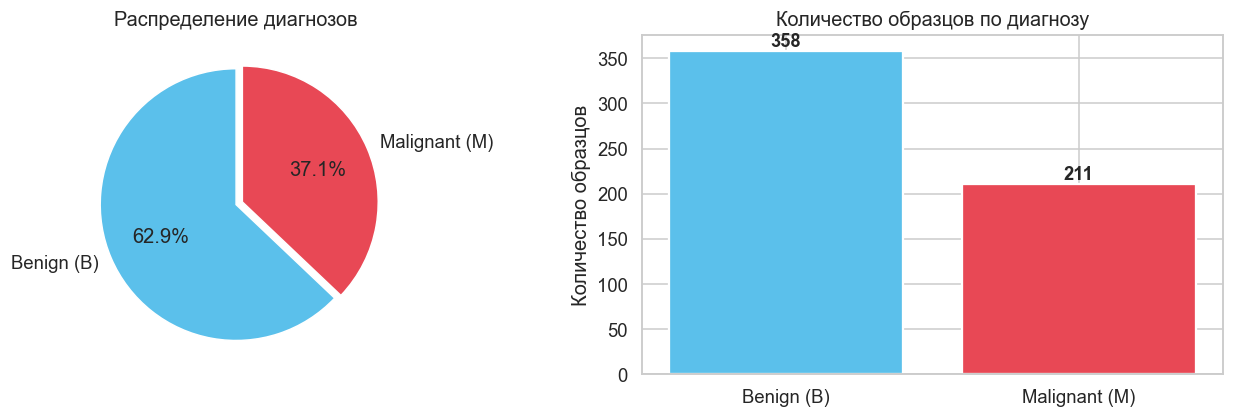

 63% доброкачественных, 37% злокачественных 


In [24]:
# E1. Распределение диагнозов (matplotlib)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


# Pie chart
counts = df_clean['diagnosis'].value_counts()
axes[0].pie(counts, labels=['Benign (B)', 'Malignant (M)'],
            autopct='%1.1f%%', colors=['#5bc0eb', '#e84855'],
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Распределение диагнозов', fontsize=13)


# Count bar
axes[1].bar(['Benign (B)', 'Malignant (M)'], counts,
            color=['#5bc0eb', '#e84855'], edgecolor='white', linewidth=1.5)
axes[1].set_ylabel('Количество образцов')
axes[1].set_title('Количество образцов по диагнозу', fontsize=13)
for i, v in enumerate(counts):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig('bio_plot1_diagnosis.png', bbox_inches='tight')
plt.show()
print(" 63% доброкачественных, 37% злокачественных ")


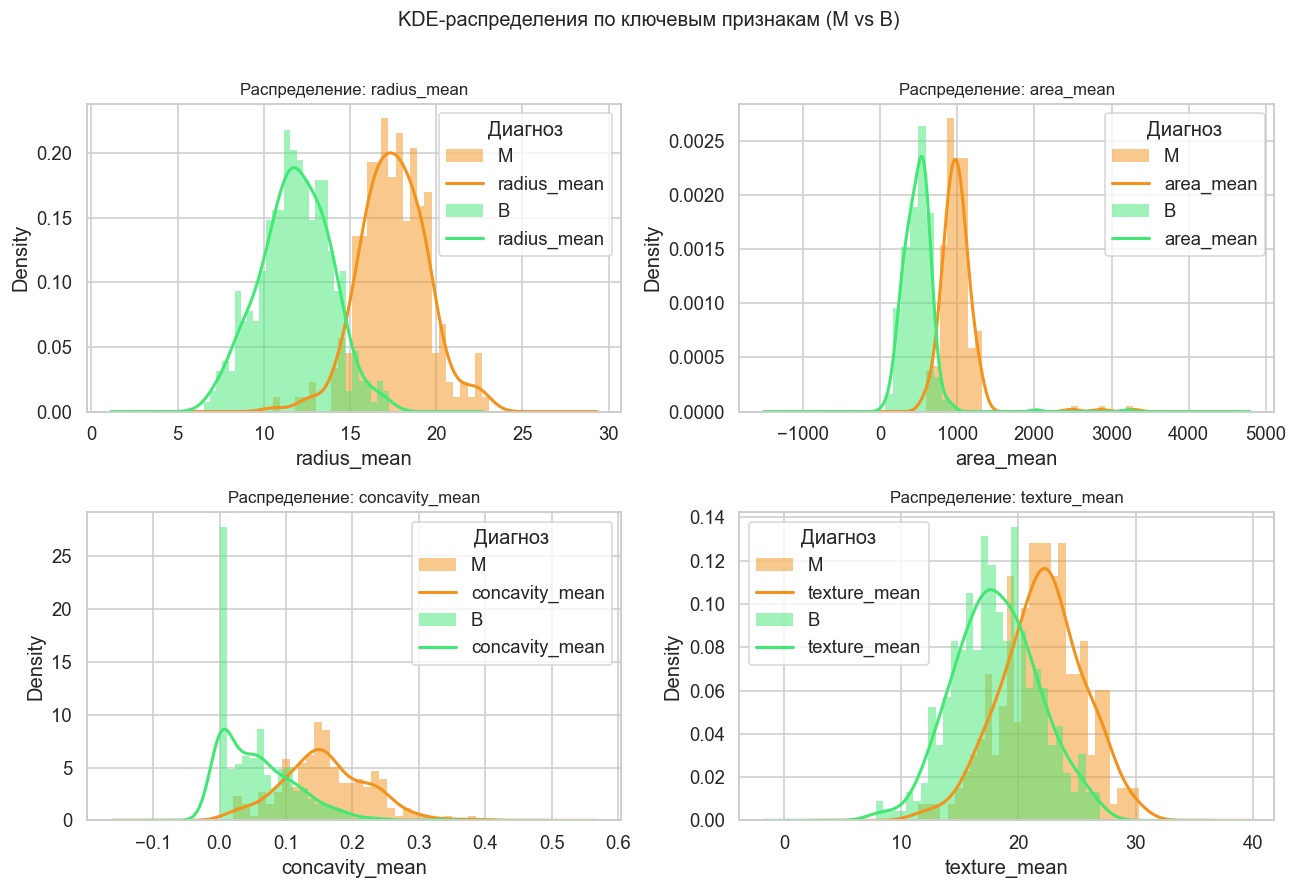

► Распределения M и B хорошо разделяются по radius_mean, area_mean, concavity_mean


In [25]:
# E2. KDE-распределения ключевых признаков по диагнозу (seaborn)
key_features = ['radius_mean', 'area_mean', 'concavity_mean', 'texture_mean']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

palette = {'M': "#f3921c", 'B': "#41e974"}

for i, col in enumerate(key_features):
    for diag, color in palette.items():
        subset = df_clean[df_clean['diagnosis'] == diag][col]
        axes[i].hist(subset, bins=30, alpha=0.5, color=color,
                     density=True, label=diag, edgecolor='none')
        subset.plot.kde(ax=axes[i], color=color, lw=2)
    axes[i].set_title(f'Распределение: {col}', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].legend(title='Диагноз')

plt.suptitle('KDE-распределения по ключевым признакам (M vs B)', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('bio_plot2_kde.png', bbox_inches='tight')
plt.show()
print("► Распределения M и B хорошо разделяются по radius_mean, area_mean, concavity_mean")


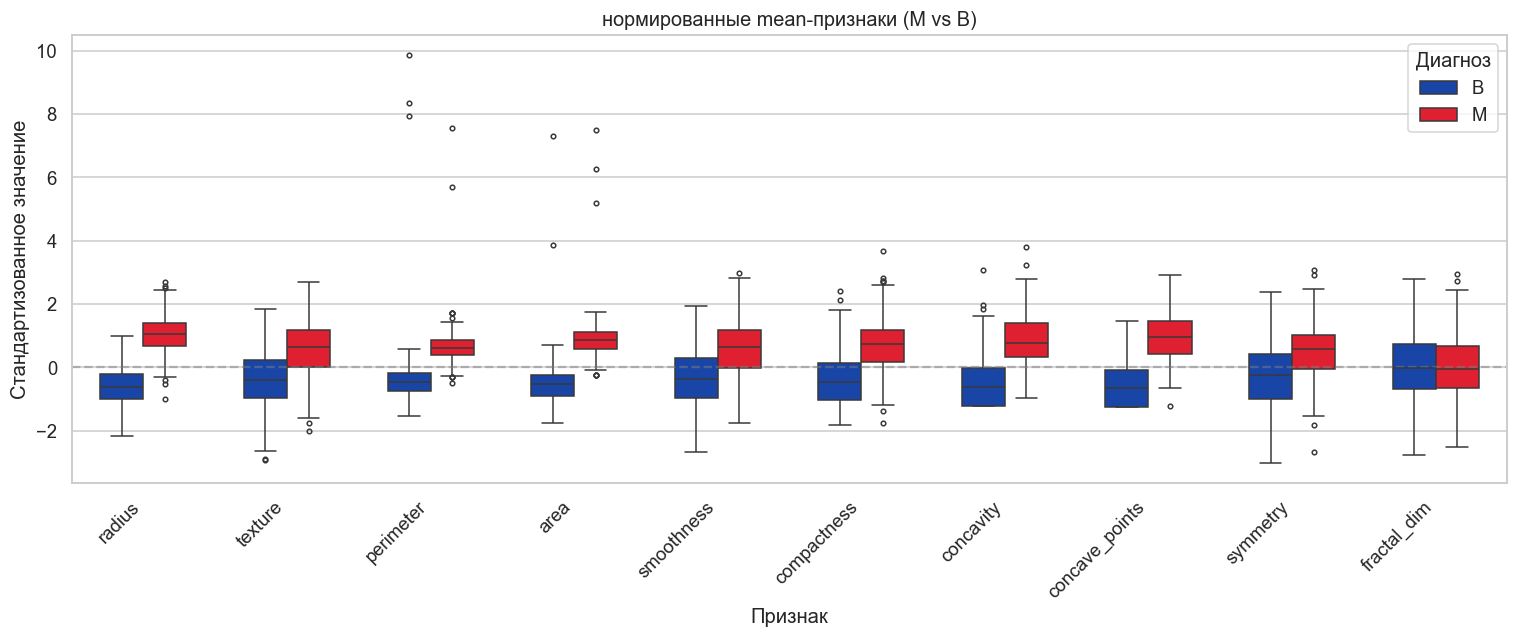

 Злокачественные (M) стабильно выше по всем морфологическим признакам кроме fractal_dim


In [ ]:
# E3. Box plots: сравнение M vs B по mean-признакам (seaborn)
# Нормируем для визуализации на одном графике
from sklearn.preprocessing import StandardScaler



scaler = StandardScaler()
mean_cols_vis = [c for c in df_clean.columns if c.endswith('_mean')]
df_scaled = df_clean.copy()
df_scaled[mean_cols_vis] = scaler.fit_transform(df_clean[mean_cols_vis])



df_melt = df_scaled[mean_cols_vis + ['diagnosis']].melt(
    id_vars='diagnosis', var_name='feature', value_name='scaled_value'
)
df_melt['feature'] = df_melt['feature'].str.replace('_mean', '')



plt.figure(figsize=(14, 6))
sns.boxplot(data=df_melt, x='feature', y='scaled_value', hue='diagnosis',
            palette={'M': "#ff0015", 'B': "#023dbd"}, width=0.6, fliersize=3)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)

plt.xticks(rotation=45, ha='right')
plt.title('нормированные mean-признаки (M vs B)', fontsize=13)

plt.xlabel('Признак')
plt.ylabel('Стандартизованное значение')
plt.legend(title='Диагноз')


plt.tight_layout()
plt.savefig('bio_plot3_boxplot.png', bbox_inches='tight')
plt.show()
print(" Злокачественные (M) стабильно выше по всем морфологическим признакам кроме fractal_dim")


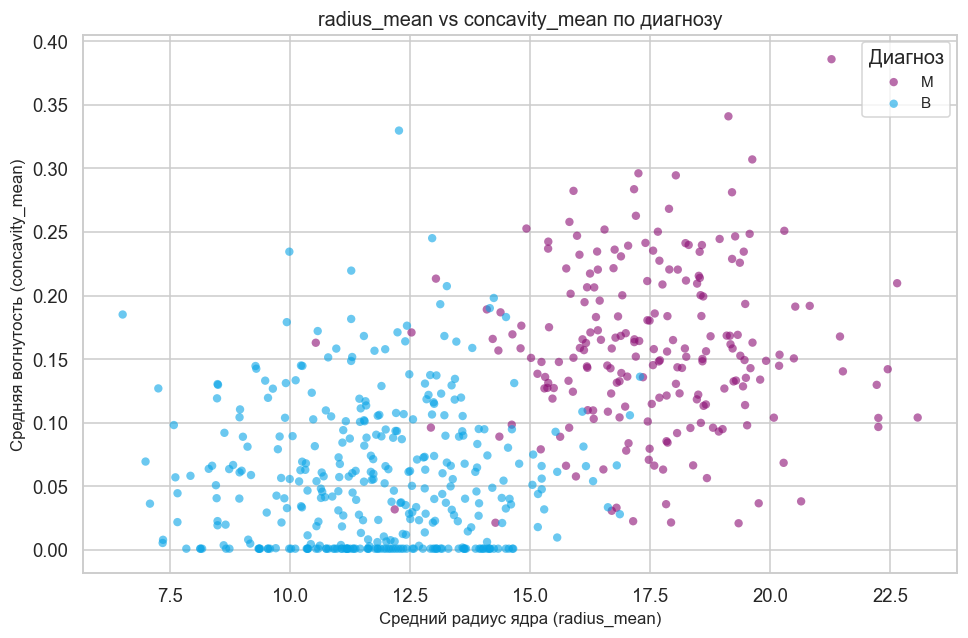

Злокачественные (красные) концентрируются в правом верхнем углу — крупнее и вогнутее


In [27]:
# E4. Scatter plot: radius_mean vs concavity_mean (matplotlib)
fig, ax = plt.subplots(figsize=(9, 6))

for diag, color in {'M': "#8b0e74", 'B': "#09a4e6"}.items():
    subset = df_clean[df_clean['diagnosis'] == diag]
    ax.scatter(subset['radius_mean'], subset['concavity_mean'],
               alpha=0.6, s=30, c=color, label=diag, edgecolors='none')

ax.set_xlabel('Средний радиус ядра (radius_mean)', fontsize=11)
ax.set_ylabel('Средняя вогнутость (concavity_mean)', fontsize=11)
ax.set_title('radius_mean vs concavity_mean по диагнозу', fontsize=13)
ax.legend(title='Диагноз', fontsize=10)


plt.tight_layout()
plt.savefig('bio_plot4_scatter.png', bbox_inches='tight')
plt.show()
print("Злокачественные (красные) концентрируются в правом верхнем углу — крупнее и вогнутее")


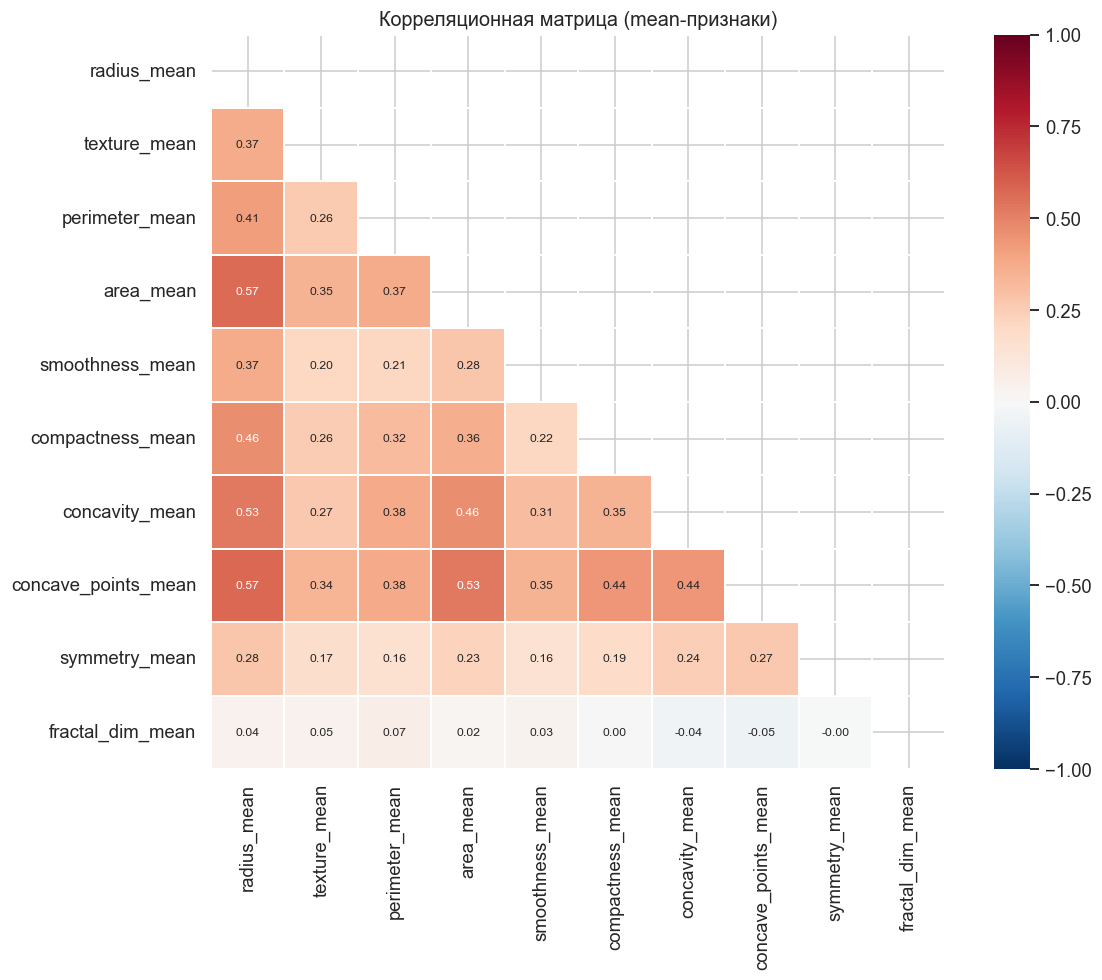

Топ-5 коррелирующих пар:
                 f1          f2        r    abs_r
concave_points_mean radius_mean 0.573217 0.573217
          area_mean radius_mean 0.569122 0.569122
concave_points_mean   area_mean 0.531190 0.531190
     concavity_mean radius_mean 0.529662 0.529662
   compactness_mean radius_mean 0.464631 0.464631


In [28]:
# E5. Heatmap корреляций (seaborn)
mean_cols_heat = [c for c in df_clean.columns if c.endswith('_mean')]
corr = df_clean[mean_cols_heat].corr()

plt.figure(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.3, vmin=-1, vmax=1,
            annot_kws={'size': 8})
plt.title('Корреляционная матрица (mean-признаки)', fontsize=13)
plt.tight_layout()
plt.savefig('bio_plot5_heatmap.png', bbox_inches='tight')
plt.show()

# Топ-5 коррелирующих пар
corr_pairs = (corr.where(~mask).stack()
              .reset_index().rename(columns={'level_0':'f1','level_1':'f2', 0:'r'}))
corr_pairs['abs_r'] = corr_pairs['r'].abs()
print("Топ-5 коррелирующих пар:")
print(corr_pairs.sort_values('abs_r', ascending=False).head(5).to_string(index=False))


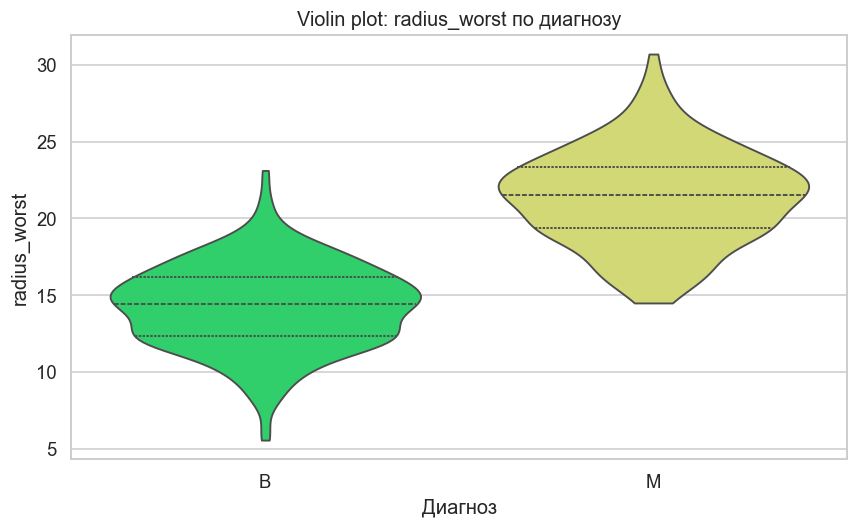

 Распределение radius_worst у M шире и смещено выше — злокачественные опухоли крупнее даже в наихудшем ядре


In [ ]:
# E6. Violin plot: сравнение radius_worst по диагнозу (seaborn)
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, x='diagnosis', y='radius_worst',
               palette={'M': "#e1e867", 'B': "#16ea64"},
               inner='quartile', cut=0)

plt.title('Violin plot: radius_worst по диагнозу', fontsize=13)
plt.xlabel('Диагноз')
plt.ylabel('radius_worst')

plt.tight_layout()
plt.savefig('bio_plot6_violin.png', bbox_inches='tight')
plt.show()
print(" Распределение radius_worst у M шире и смещено выше — злокачественные опухоли крупнее даже в наихудшем ядре")


In [30]:
# E7. Plotly: интерактивный scatter с hover_data
df_plot = df_clean.copy()
df_plot['diagnosis_label'] = df_plot['diagnosis'].map({'M': 'Malignant', 'B': 'Benign'})

fig = px.scatter(
    df_plot,
    x = 'area_mean',
    y = 'concave_points_mean',
    color = 'diagnosis_label',
    color_discrete_map = {'Malignant': "#f5081c", 'Benign': "#c60ff9"},
    hover_data = ['radius_mean', 'texture_mean', 'smoothness_mean'],
    title = 'area_mean vs concave_points_mean (Plotly, интерактивный)',
    labels = {
        'area_mean': 'Средняя площадь (area_mean)',
        'concave_points_mean': 'Вогнутые точки (concave_points_mean)',
        'diagnosis_label': 'Диагноз'
    },
    opacity = 0.7
)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()
print("► Классы хорошо разделяются — это хороший признак для классификатора")


► Классы хорошо разделяются — это хороший признак для классификатора


In [31]:
# E8. Plotly: box plot nuclear_score (новый признак) по диагнозу
fig2 = px.box(
    df_enc,
    x = 'diagnosis',
    y = 'nuclear_score',
    color = 'diagnosis',
    color_discrete_map = {'M': "#78df8b", 'B': '#5bc0eb'},
    title = 'nuclear_score (area_mean × concavity_mean) по диагнозу',
    labels = {'nuclear_score': 'nuclear_score', 'diagnosis': 'Диагноз'},
    points = 'outliers'
)
fig2.update_layout(plot_bgcolor='white', paper_bgcolor='white', showlegend=False)
fig2.show()
print(" nuclear_score у M в ~6 раз выше чем у B — признак хорошо разделяет классы")


 nuclear_score у M в ~6 раз выше чем у B — признак хорошо разделяет классы



 ---
## F. Итоговые выводы пу-пу-пу

### Что я поняла про датасет

- Все 30 признаков — это характеристики клеточных ядер из изображения биопсии. Они разделены на три группы: **mean** (среднее значение), **se** (стандартная ошибка) и **worst** (самые «плохие» три ядра). Это круто придумано (можно видеть как типичную картину, так и самые агрессивные клетки)

- Классы довольно хорошо разделяются. Особенно по `radius_mean`, `area_mean`, `concavity_mean` и `concave_points_mean`. Злокачественные опухоли (M) визуально заметно отличаются от доброкачественных (B)

- Сильная мультиколлинеарность: radius, perimeter и area очень сильно коррелируют (r > 0.95). Это логично т к площадь же примерно π·r². Значит при обучении модели придётся что-то с этим делать (регуляризация или PCA)

- Пропуски есть, но они выглядят случайными (MCAR). Паттерна по диагнозу нет, поэтому я заполнила их медианой (она устойчивее к выбросам)

- Дисбаланс классов умеренный: примерно 63% B и 37% M. Accuracy может быть обманчивой, поэтому лучше смотреть на precision/recall/F1, особенно для класса M

- В данных есть выбросы (особенно в `area_mean` и `area_worst`). При дальнейшей работе с ними нужно быть аккуратнее

- Признаки из группы **worst** оказались информативнее, чем mean. Злокачественные опухоли часто «выдают» себя именно в самых плохих ядрах

- Новый признак `nuclear_score = area_mean × concavity_mean` получился удачным. Он хорошо разделяет классы и отражает «агрессивность» ядра

- Злокачественные опухоли чуть более неоднородные, у них `size_ratio` (worst/mean) в среднем выше

- Новый признак nuclear_score работает. Произведение area_mean × concavity_mean даёт значимое разделение (p < 0.001) и он отражает «агрессивность» ядра

- size_ratio (~1.2 у M vs ~1.1 у B). Злокачественные опухоли неоднороднее, то бок их worst-ядра крупнее среднего сильнее, чем у доброкачественных



---
